# Stock Portfolio Optimization Using Modern Portfolio Theory

In [ ]:
This project implements a quantitative portfolio optimization framework using Modern Portfolio Theory (MPT). 
The objective is to construct an optimal portfolio that maximizes risk-adjusted return using Monte Carlo simulation, 
Sharpe ratio optimization, and risk metrics such as Value at Risk (VaR) and Maximum Drawdown.

## 1. Import Libraries

In [ ]:
This section imports the required Python libraries for financial data collection, numerical computation, 
data manipulation, and visualization. NumPy and Pandas are used for mathematical operations, 
while Matplotlib and Seaborn are used for graphical representation of results.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')

Matplotlib is building the font cache; this may take a moment.


## 2. Stock Selection

In [ ]:
In this section, a diversified set of large-cap Indian stocks is selected across multiple sectors 
such as Energy, IT, and Banking. Diversification is important in portfolio theory 
to reduce unsystematic risk through low correlation between assets.

In [2]:
stocks = ['RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'HDFCBANK.NS', 'ICICIBANK.NS']

## 3. Data Collection

In [ ]:
Historical stock price data is downloaded using the yfinance API. 
We use closing prices to compute daily returns, which form the foundation 
for risk and return analysis in portfolio optimization.

In [6]:
data = yf.download(stocks, start="2018-01-01", end="2024-01-01")

# Select Close prices
data = data['Close']

data.head()

[*********************100%***********************]  5 of 5 completed


Ticker,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2018-01-01,432.689026,298.055023,415.244263,401.864777,1083.771484
2018-01-02,436.853760,297.478760,413.697449,402.483215,1077.872681
2018-01-03,432.257416,302.569580,410.322601,404.095551,1080.924316
2018-01-04,433.948975,302.281403,407.952179,406.525055,1088.482422
2018-01-05,434.812225,300.552429,406.586212,407.828156,1101.632202


## 4. Data Preprocessing & Return Calculation

In [ ]:
Daily percentage returns are calculated from price data. 
Returns are used instead of raw prices because they standardize performance 
and allow meaningful statistical analysis of risk and return.

In [7]:
returns = data.pct_change().dropna()
returns.head()

Ticker,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2018-01-02,0.009625,-0.001933,-0.003725,0.001539,-0.005443
2018-01-03,-0.010521,0.017113,-0.008158,0.004006,0.002831
2018-01-04,0.003913,-0.000952,-0.005777,0.006012,0.006992
2018-01-05,0.001989,-0.005720,-0.003348,0.003205,0.012081
2018-01-08,-0.001610,0.003995,0.023765,0.005741,0.009371


## 5. Risk Metrics (Return, Volatility, Covariance)

In [ ]:
This section computes annualized expected returns, volatility, and the covariance matrix. 
These metrics are core inputs in Modern Portfolio Theory, 
as portfolio risk depends on both individual asset volatility and asset correlations.

In [8]:
# Annual expected return
mean_returns = returns.mean() * 252

# Annual volatility (risk)
volatility = returns.std() * np.sqrt(252)

print("Expected Annual Returns:")
print(mean_returns)

print("\nAnnual Volatility:")
print(volatility)

Expected Annual Returns:
Ticker
HDFCBANK.NS     0.143699
ICICIBANK.NS    0.256277
INFY.NS         0.252842
RELIANCE.NS     0.241992
TCS.NS          0.232363
dtype: float64

Annual Volatility:
Ticker
HDFCBANK.NS     0.254474
ICICIBANK.NS    0.326561
INFY.NS         0.280307
RELIANCE.NS     0.298120
TCS.NS          0.249462
dtype: float64


## 6. Monte Carlo Portfolio Simulation

In [ ]:
Monte Carlo simulation is used to generate thousands of random portfolio weight combinations. 
For each portfolio, expected return, volatility, and Sharpe ratio are calculated 
to evaluate risk-adjusted performance.

In [9]:
cov_matrix = returns.cov() * 252
cov_matrix

Ticker,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Ticker,,,,,
HDFCBANK.NS,0.064757,0.048298,0.021969,0.031251,0.017275
ICICIBANK.NS,0.048298,0.106642,0.025397,0.038519,0.019739
INFY.NS,0.021969,0.025397,0.078572,0.024939,0.043449
RELIANCE.NS,0.031251,0.038519,0.024939,0.088875,0.023658
TCS.NS,0.017275,0.019739,0.043449,0.023658,0.062231


## 7. Optimal Portfolio Selection

In [ ]:
The portfolio with the maximum Sharpe ratio is selected as the optimal portfolio. 
This represents the allocation that provides the highest return per unit of risk.

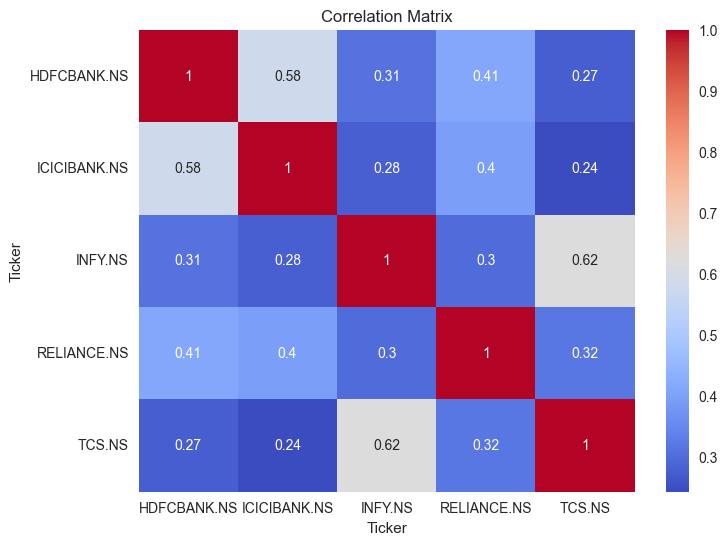

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(returns.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## 8. Efficient Frontier Visualization

In [ ]:
The Efficient Frontier visualizes the trade-off between risk and return across simulated portfolios. 
The optimal portfolio is highlighted to show the most efficient allocation 
in terms of risk-adjusted performance.

In [11]:
num_portfolios = 10000
num_stocks = len(stocks)

results = np.zeros((3, num_portfolios))
weights_record = []

In [12]:
for i in range(num_portfolios):
    
    # Generate random weights
    weights = np.random.random(num_stocks)
    weights /= np.sum(weights)
    weights_record.append(weights)
    
    # Portfolio return
    portfolio_return = np.dot(weights, mean_returns)
    
    # Portfolio volatility
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    
    # Sharpe ratio (assuming risk-free rate = 0)
    sharpe_ratio = portfolio_return / portfolio_volatility
    
    # Store results
    results[0,i] = portfolio_return
    results[1,i] = portfolio_volatility
    results[2,i] = sharpe_ratio

In [13]:
max_sharpe_idx = np.argmax(results[2])
optimal_weights = weights_record[max_sharpe_idx]

print("🔹 Optimal Portfolio Weights:")
for stock, weight in zip(stocks, optimal_weights):
    print(stock, ":", round(weight*100, 2), "%")

print("\nExpected Annual Return:", round(results[0, max_sharpe_idx], 4))
print("Annual Volatility:", round(results[1, max_sharpe_idx], 4))
print("Sharpe Ratio:", round(results[2, max_sharpe_idx], 4))

🔹 Optimal Portfolio Weights:
RELIANCE.NS : 0.23 %
TCS.NS : 18.97 %
INFY.NS : 25.72 %
HDFCBANK.NS : 24.72 %
ICICIBANK.NS : 30.36 %

Expected Annual Return: 0.2443
Annual Volatility: 0.2054
Sharpe Ratio: 1.1894


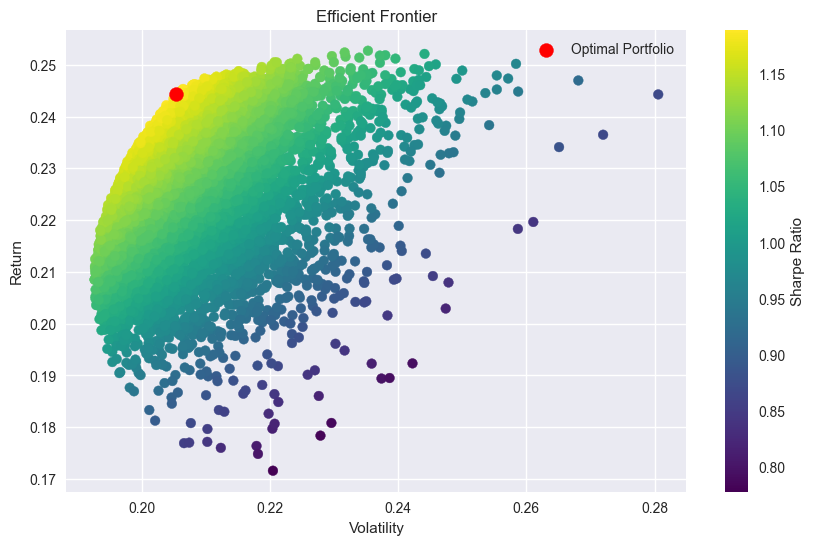

In [14]:
plt.figure(figsize=(10,6))

plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap='viridis')
plt.colorbar(label='Sharpe Ratio')

plt.scatter(results[1,max_sharpe_idx],
            results[0,max_sharpe_idx],
            color='red', s=100, label='Optimal Portfolio')

plt.xlabel('Volatility')
plt.ylabel('Return')
plt.title('Efficient Frontier')
plt.legend()

plt.show()

## 9. Risk Analysis (VaR & Maximum Drawdown)

In [ ]:
Additional risk metrics such as Value at Risk (VaR) and Maximum Drawdown are calculated 
to evaluate downside risk. VaR estimates potential loss at a given confidence level, 
while Maximum Drawdown measures the largest peak-to-trough decline during the investment period.

In [15]:
portfolio_returns = returns.dot(optimal_weights)

VaR_95 = np.percentile(portfolio_returns, 5)

print("95% Daily Value at Risk:", round(VaR_95,4))

95% Daily Value at Risk: -0.017


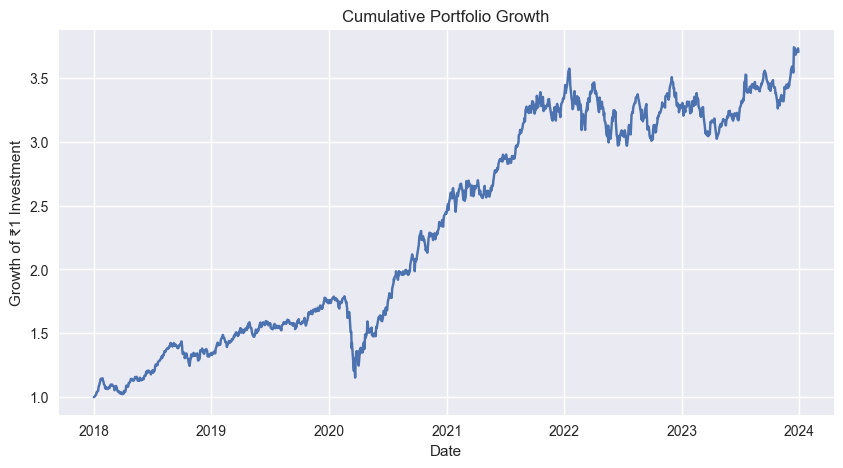

In [16]:
cumulative_returns = (1 + portfolio_returns).cumprod()

plt.figure(figsize=(10,5))
plt.plot(cumulative_returns)
plt.title("Cumulative Portfolio Growth")
plt.xlabel("Date")
plt.ylabel("Growth of ₹1 Investment")
plt.show()

In [17]:
rolling_max = cumulative_returns.cummax()
drawdown = cumulative_returns / rolling_max - 1

max_drawdown = drawdown.min()

print("Maximum Drawdown:", round(max_drawdown,4))

Maximum Drawdown: -0.3564


In [18]:
print("\n----- FINAL PORTFOLIO SUMMARY -----")
print("Expected Annual Return:", round(results[0,max_sharpe_idx]*100,2), "%")
print("Annual Volatility:", round(results[1,max_sharpe_idx]*100,2), "%")
print("Sharpe Ratio:", round(results[2,max_sharpe_idx],2))
print("95% Daily VaR:", round(VaR_95*100,2), "%")
print("Maximum Drawdown:", round(max_drawdown*100,2), "%")


----- FINAL PORTFOLIO SUMMARY -----
Expected Annual Return: 24.43 %
Annual Volatility: 20.54 %
Sharpe Ratio: 1.19
95% Daily VaR: -1.7 %
Maximum Drawdown: -35.64 %
